<a href="https://colab.research.google.com/github/esigelecParfait/Projet-Spark/blob/main/Projet_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Ville").getOrCreate()
"""Charger le fichier ville_1.csv dans un DataFrame et afficher les premières lignes"""
df = spark.read.csv( r"/content/sample_data/ville_1.csv",header=True, inferSchema=True)
#df.show(10)
"""Afficher les types de colonnes de ce fichier"""
df.dtypes
nbre_ligne_fichier_ville=df.count()
print(nbre_ligne_fichier_ville)

1083


In [2]:
df_homme=df.filter(df.sexe=="H")
df_femme=df.filter(df.sexe=="F")

In [3]:
df.groupBy("sexe").count().show()

df.createOrReplaceTempView("villes")
spark.sql("SELECT COUNT(*), SEXE  AS nb FROM VILLES GROUP BY SEXE ").show()

+----+-----+
|sexe|count|
+----+-----+
|   F|  523|
|   H|  560|
+----+-----+

+--------+---+
|count(1)| nb|
+--------+---+
|     523|  F|
|     560|  H|
+--------+---+



In [4]:
spark.sql("SELECT AVG(SALAIRE) AS MOYENNE_SALAIRE FROM VILLES ").show()

+------------------+
|   MOYENNE_SALAIRE|
+------------------+
|25943.173561933854|
+------------------+



In [5]:
from pyspark.sql.functions import avg,mean
df.agg(avg("salaire")).show()
df.show()
from pyspark.sql.types import DoubleType
df=df.withColumn("salary",df["salaire"].cast(DoubleType()))
moyenne=df.select(mean("salary")).show()



+------------------+
|      avg(salaire)|
+------------------+
|25943.173561933854|
+------------------+

+----+--------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+
|  id|      vitesse_a_pied|     vitesse_a_velo|                home|             travail|sportif|casseur|              statut|           salaire|sexe|age|         sportivite|velo_perf_minimale|
+----+--------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+
|5251|                0.02|               0.05|(lon:26.60 lat:28...|(lon:21.08 lat:14...|  false|  false|          reserviste|29800.610034665042|   F| 18|                0.1|               0.4|
|5252| 0.14974625830876215|0.37436564577190534|(lon:0.26 lat:42.61)|(lon:36.35 lat:33...|  false|  false|          pro

In [6]:
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

def tranche(salaire):
    if salaire is None:
        return None
    if salaire < 10000:
        return 0
    return int(salaire // 10000)

classe = udf(tranche, IntegerType())
df = df.withColumn("Classe", classe(df["salaire"]))
df.show()

+----+--------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+------------------+------+
|  id|      vitesse_a_pied|     vitesse_a_velo|                home|             travail|sportif|casseur|              statut|           salaire|sexe|age|         sportivite|velo_perf_minimale|            salary|Classe|
+----+--------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+------------------+------+
|5251|                0.02|               0.05|(lon:26.60 lat:28...|(lon:21.08 lat:14...|  false|  false|          reserviste|29800.610034665042|   F| 18|                0.1|               0.4|29800.610034665042|     2|
|5252| 0.14974625830876215|0.37436564577190534|(lon:0.26 lat:42.61)|(lon:36.35 lat:33...|  false|  false|          profe

In [7]:
tranche_salaire=df.groupBy("Classe").count()
tranche_salaire.show()

+------+-----+
|Classe|count|
+------+-----+
|     1|  295|
|     6|    3|
|     3|  222|
|     5|   14|
|     4|   65|
|     8|    1|
|     7|    1|
|     2|  476|
|     0|    6|
+------+-----+



In [8]:
df.sort("sexe","classe").show()

+----+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+------------------+------+
|  id|     vitesse_a_pied|     vitesse_a_velo|                home|             travail|sportif|casseur|              statut|           salaire|sexe|age|         sportivite|velo_perf_minimale|            salary|Classe|
+----+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+------------------+------+
|5375|               0.02|               0.05|(lon:26.11 lat:3.34)|(lon:25.13 lat:7.51)|  false|  false|             employe|  7392.30996558039|   F| 55|                0.1|               0.4|  7392.30996558039|     0|
|6031|0.08328838658186277|0.20822096645465696|(lon:19.32 lat:8.60)|(lon:37.95 lat:25...|  false|  false|technicien_de_sur...

In [9]:
from pyspark.sql.functions import collect_list,collect_set,size
df.groupBy("sexe").agg(size(collect_set("id")),size(collect_set("classe"))).show()


+----+---------------------+-------------------------+
|sexe|size(collect_set(id))|size(collect_set(classe))|
+----+---------------------+-------------------------+
|   F|                  523|                        7|
|   H|                  560|                        9|
+----+---------------------+-------------------------+



In [34]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("CyclistesLogs").getOrCreate()

df = spark.read.csv(r"/content/sample_data/Cycliste/*.csv",header=True)
cycliste=df

In [11]:
from pyspark.sql.functions import col
df.filter(col("id")==2).show(5)

+---+-------------------+--------+-----+-------+--------------------+------------------+
| id|          timestamp|sur_velo| velo|vitesse|            position|destination_finale|
+---+-------------------+--------+-----+-------+--------------------+------------------+
|  2|2018-01-01 00:01:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:02:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:03:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:04:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:05:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
+---+-------------------+--------+-----+-------+--------------------+------------------+
only showing top 5 rows


In [12]:
df.count()

4868396

In [13]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- sur_velo: string (nullable = true)
 |-- velo: string (nullable = true)
 |-- vitesse: string (nullable = true)
 |-- position: string (nullable = true)
 |-- destination_finale: string (nullable = true)



In [14]:
df = df.dropDuplicates(["id", "timestamp"])

In [15]:
df.count()

4868396

In [16]:
from pyspark.sql.functions import col


df.filter(col("id")==246).show(10)

+---+-------------------+--------+-----+-------+--------------------+------------------+
| id|          timestamp|sur_velo| velo|vitesse|            position|destination_finale|
+---+-------------------+--------+-----+-------+--------------------+------------------+
|246|2018-01-01 00:01:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:02:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:03:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:04:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:05:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:06:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:07:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:08:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:09

In [17]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, lag

window = Window.partitionBy("id").orderBy("timestamp")

In [18]:
df = df.withColumn(
    "prev_sur_velo",
    lag("sur_velo").over(window)
)

In [19]:
from pyspark.sql.functions import when

df = df.withColumn(
    "start_trip",
    when(
        (col("sur_velo") == True) & (col("prev_sur_velo") == False),
        1
    ).otherwise(0)
)

In [20]:
from pyspark.sql.functions import sum as spark_sum

df = df.withColumn(
    "trip_id",
    spark_sum("start_trip").over(window)
)

In [21]:
from pyspark.sql.functions import to_timestamp

df = df.withColumn(
    "timestamp",
    to_timestamp("timestamp")
)

In [22]:
from pyspark.sql.functions import min, max,col

trajets = df.filter(col("sur_velo") == True) \
    .groupBy("id", "trip_id") \
    .agg(
        min("timestamp").alias("start_time"),
        max("timestamp").alias("end_time")
    )
trajets.filter(col("id") == 246).show()

+---+-------+-------------------+-------------------+
| id|trip_id|         start_time|           end_time|
+---+-------+-------------------+-------------------+
|246|      1|2018-01-01 04:17:00|2018-01-01 14:27:00|
|246|      2|2018-01-01 16:18:00|2018-01-02 06:12:00|
|246|      3|2018-01-02 07:17:00|2018-01-02 22:17:00|
|246|      4|2018-01-02 22:44:00|2018-01-03 15:33:00|
|246|      5|2018-01-03 17:58:00|2018-01-04 11:51:00|
|246|      6|2018-01-04 16:18:00|2018-01-05 09:09:00|
|246|      7|2018-01-05 10:17:00|2018-01-14 11:16:00|
+---+-------+-------------------+-------------------+



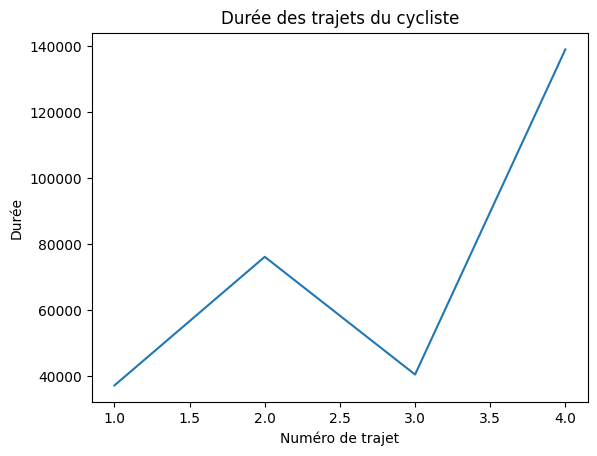

In [23]:
trajets = trajets.withColumn(
    "duration",
    col("end_time") - col("start_time")
)
graphique=trajets.toPandas()
graphique['duration']=graphique['duration'].dt.total_seconds()

graphique = graphique[graphique['id'] == "2"]


import matplotlib.pyplot as plt

plt.figure()

plt.plot(graphique["trip_id"], graphique["duration"])

plt.xlabel("Numéro de trajet")
plt.ylabel("Durée")
plt.title("Durée des trajets du cycliste")

plt.show()



In [24]:
from pyspark.sql import SparkSession
import pandas as pd
spark=SparkSession.builder.appName('practice').getOrCreate()
prestataire=spark.read.csv(r"/content/sample_data/Prestataire_1.csv",header=True,inferSchema=True)
prestataire.show(5)
villes=spark.read.csv(r"/content/sample_data/ville_1.csv",header=True,inferSchema=True)
villes.show(5)


+-------------+-------+-------+
|           id|largeur|hauteur|
+-------------+-------+-------+
|Prestataire_1|     50|     50|
+-------------+-------+-------+

+----+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+
|  id|     vitesse_a_pied|     vitesse_a_velo|                home|             travail|sportif|casseur|              statut|           salaire|sexe|age|         sportivite|velo_perf_minimale|
+----+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+------------------+----+---+-------------------+------------------+
|5251|               0.02|               0.05|(lon:26.60 lat:28...|(lon:21.08 lat:14...|  false|  false|          reserviste|29800.610034665042|   F| 18|                0.1|               0.4|
|5252|0.14974625830876215|0.37436564577190534|(lon:0.26 lat:42.61)|

Non, l'affichage avec "show" n'est pas adapté.

In [25]:
echantillon_villes=villes.sample(False,0.7,42)


In [26]:
villes_pd=villes.toPandas()
villes_pd.head()

,id,vitesse_a_pied,vitesse_a_velo,home,travail,sportif,casseur,statut,salaire,sexe,age,sportivite,velo_perf_minimale
0,5251,0.020000,0.050000,(lon:26.60 lat:28.13),(lon:21.08 lat:14.11),False,False,reserviste,29800.610035,F,18,0.100000,0.4
1,5252,0.149746,0.374366,(lon:0.26 lat:42.61),(lon:36.35 lat:33.28),False,False,professeur,23595.443840,F,28,0.748731,0.4
2,5253,0.630971,1.682590,(lon:3.34 lat:13.95),(lon:24.75 lat:48.15),False,False,technicien_de_surface,18530.147763,H,65,2.103237,0.4
3,5254,0.040096,0.106923,(lon:19.54 lat:43.69),(lon:38.57 lat:42.65),False,False,technicien_de_surface,18997.602810,H,26,0.133653,0.4
4,5255,0.020000,0.050000,(lon:28.51 lat:41.70),(lon:17.67 lat:25.16),False,False,éboueur,23618.479750,F,50,0.100000,0.4


In [27]:
velos=spark.read.csv(r"/content/sample_data/velos/*.csv",header=True,inferSchema=True)
velos.show(5)
velos.count()

+--------+-------------------+-------------------+
| velo_id|        performance|          timestamp|
+--------+-------------------+-------------------+
|velo_221| 0.8475528879954313|2018-01-05 16:14:00|
|velo_221|0.14821009714870595|2018-01-06 20:23:00|
|velo_221|0.14658190917531475|2018-01-07 06:04:00|
|velo_221|0.14537679499231898|2018-01-07 08:51:00|
|velo_221|0.14305306724092204|2018-01-07 11:42:00|
+--------+-------------------+-------------------+
only showing top 5 rows


17529

In [28]:
stations=spark.read.csv(r"/content/sample_data/stations/*.csv",header=True,inferSchema=True)
stations.show(5)
stations.count()

+-------------------+----------+-----------+----------+-----------------+---------+
|          timestamp|station_id|cycliste_id|   velo_id| velo_performance|   action|
+-------------------+----------+-----------+----------+-----------------+---------+
|          timestamp|station_id|cycliste_id|   velo_id|             NULL|   action|
|          timestamp|station_id|performance|      NULL|             NULL|     NULL|
|2018-01-01 04:02:00|        24|       3188|velo_11132|0.936689745950615|recuperer|
|2018-01-01 04:02:00|        24|          1|      NULL|             NULL|     NULL|
|2018-01-01 08:28:00|        24|         77|velo_30447|             0.85|recuperer|
+-------------------+----------+-----------+----------+-----------------+---------+
only showing top 5 rows


2472

In [29]:
stations_17=spark.read.csv(r"/content/sample_data/stations/log_stations_17.csv",header=True,inferSchema=True)
stations_17.show(5)
stations_17.count()

+-------------------+----------+-----------+--------+----------------+------+
|          timestamp|station_id|cycliste_id| velo_id|velo_performance|action|
+-------------------+----------+-----------+--------+----------------+------+
|          timestamp|station_id|cycliste_id| velo_id|            NULL|action|
|          timestamp|station_id|performance|    NULL|            NULL|  NULL|
|2018-01-01 02:06:00|        17|       1531|velo_209|            0.85|donner|
|2018-01-01 02:06:00|        17|          1|    NULL|            NULL|  NULL|
|2018-01-01 10:58:00|        17|          1|    NULL|            NULL|  NULL|
+-------------------+----------+-----------+--------+----------------+------+
only showing top 5 rows


78

In [30]:
from pyspark.sql.functions import col
lignes_ecartes_17=stations_17.filter(col("station_id").isNull())
stations_prop=stations_17.exceptAll(lignes_ecartes_17)
lignes_ecart_17=stations_17.filter(col("velo_id").isNull())
stations_nettoyes_17=stations_prop.exceptAll(lignes_ecart_17)
stations_nettoyes_17.show(30)

+-------------------+----------+-----------+----------+-------------------+---------+
|          timestamp|station_id|cycliste_id|   velo_id|   velo_performance|   action|
+-------------------+----------+-----------+----------+-------------------+---------+
|2018-01-11 02:06:00|        17|       1531|  velo_219|               0.85|   donner|
|2018-01-11 12:50:00|        17|       4823| velo_2763| 0.5148958180742051|   donner|
|2018-01-10 02:06:00|        17|       1531| velo_2179| 0.4112589559465957|   donner|
|2018-01-12 18:39:00|        17|       6139| velo_2027|0.37442499789583433|   donner|
|2018-01-04 12:50:00|        17|       4823|  velo_210|               0.85|   donner|
|2018-01-03 02:06:00|        17|       1531|  velo_214|               0.85|   donner|
|2018-01-08 16:36:00|        17|       4339|  velo_213|               0.85|   donner|
|2018-01-13 05:59:00|        17|       3845| velo_2027| 0.3578112431146158|recuperer|
|2018-01-04 02:06:00|        17|       1531|  velo_218

In [31]:
lignes_entetes_17 = stations_nettoyes_17.filter(col("station_id") == "station_id")
stations_nettoyes_17 = stations_nettoyes_17.exceptAll(lignes_entetes_17)
stations_nettoyes_17.show(30, truncate=False)
stations_nettoyes_17.count()


+-------------------+----------+-----------+----------+-------------------+---------+
|timestamp          |station_id|cycliste_id|velo_id   |velo_performance   |action   |
+-------------------+----------+-----------+----------+-------------------+---------+
|2018-01-11 02:06:00|17        |1531       |velo_219  |0.85               |donner   |
|2018-01-11 12:50:00|17        |4823       |velo_2763 |0.5148958180742051 |donner   |
|2018-01-10 02:06:00|17        |1531       |velo_2179 |0.4112589559465957 |donner   |
|2018-01-12 18:39:00|17        |6139       |velo_2027 |0.37442499789583433|donner   |
|2018-01-04 12:50:00|17        |4823       |velo_210  |0.85               |donner   |
|2018-01-03 02:06:00|17        |1531       |velo_214  |0.85               |donner   |
|2018-01-08 16:36:00|17        |4339       |velo_213  |0.85               |donner   |
|2018-01-13 05:59:00|17        |3845       |velo_2027 |0.3578112431146158 |recuperer|
|2018-01-04 02:06:00|17        |1531       |velo_218  

35

Oui je constate des problèmes, les fichiers ont mal chargé dans mon dataframe, les données ne sont pas alignées de la bonne manière

Les fichiers csv de stations sont mal organisés ie l'entete est mal respecte dans ces fichiers, on retrouve plusieurs fois l'entete dans le fichier, et certains lignes n'ont pas la meme longueur correspondant au nombre de colonnes du fichier

In [32]:
from pyspark.sql.functions import col
lignes_ecartes=stations.filter(col("station_id").isNull())
stations_prop=stations.exceptAll(lignes_ecartes)
lignes_ecart=stations.filter(col("velo_id").isNull())
stations_nettoyes=stations_prop.exceptAll(lignes_ecart)
stations_nettoyes.show(30)

+-------------------+----------+-----------+----------+-------------------+---------+
|          timestamp|station_id|cycliste_id|   velo_id|   velo_performance|   action|
+-------------------+----------+-----------+----------+-------------------+---------+
|2018-01-09 10:57:00|        24|        381| velo_1296| 0.4894505987898065|recuperer|
|2018-01-07 10:02:00|        13|        760|velo_23728|-0.5101449050917827|recuperer|
|2018-01-01 18:55:00|        23|         42|  velo_345|               0.85|   donner|
|2018-01-10 17:02:00|        18|       4330|  velo_899| 0.6604631097918819|recuperer|
|2018-01-14 09:35:00|         2|       5810|velo_13985| 0.5067667756135378|   donner|
|2018-01-07 10:41:00|        19|        568| velo_1393| 0.7374818247520174|recuperer|
|2018-01-13 10:43:00|        14|       2565|  velo_165|               0.85|   donner|
|2018-01-10 09:49:00|        24|        381|velo_11683| 0.2727826387223332|   donner|
|2018-01-11 17:29:00|        24|         77| velo_2984

In [33]:
lignes_entetes = stations_nettoyes.filter(col("station_id") == "station_id")
stations_nettoyes = stations_nettoyes.exceptAll(lignes_entetes)
stations_nettoyes.show(30, truncate=False)


+-------------------+----------+-----------+----------+-------------------+---------+
|timestamp          |station_id|cycliste_id|velo_id   |velo_performance   |action   |
+-------------------+----------+-----------+----------+-------------------+---------+
|2018-01-09 10:57:00|24        |381        |velo_1296 |0.4894505987898065 |recuperer|
|2018-01-07 10:02:00|13        |760        |velo_23728|-0.5101449050917827|recuperer|
|2018-01-01 18:55:00|23        |42         |velo_345  |0.85               |donner   |
|2018-01-10 17:02:00|18        |4330       |velo_899  |0.6604631097918819 |recuperer|
|2018-01-14 09:35:00|2         |5810       |velo_13985|0.5067667756135378 |donner   |
|2018-01-07 10:41:00|19        |568        |velo_1393 |0.7374818247520174 |recuperer|
|2018-01-13 10:43:00|14        |2565       |velo_165  |0.85               |donner   |
|2018-01-10 09:49:00|24        |381        |velo_11683|0.2727826387223332 |donner   |
|2018-01-11 17:29:00|24        |77         |velo_2984 

Analyse du fichier Cycliste

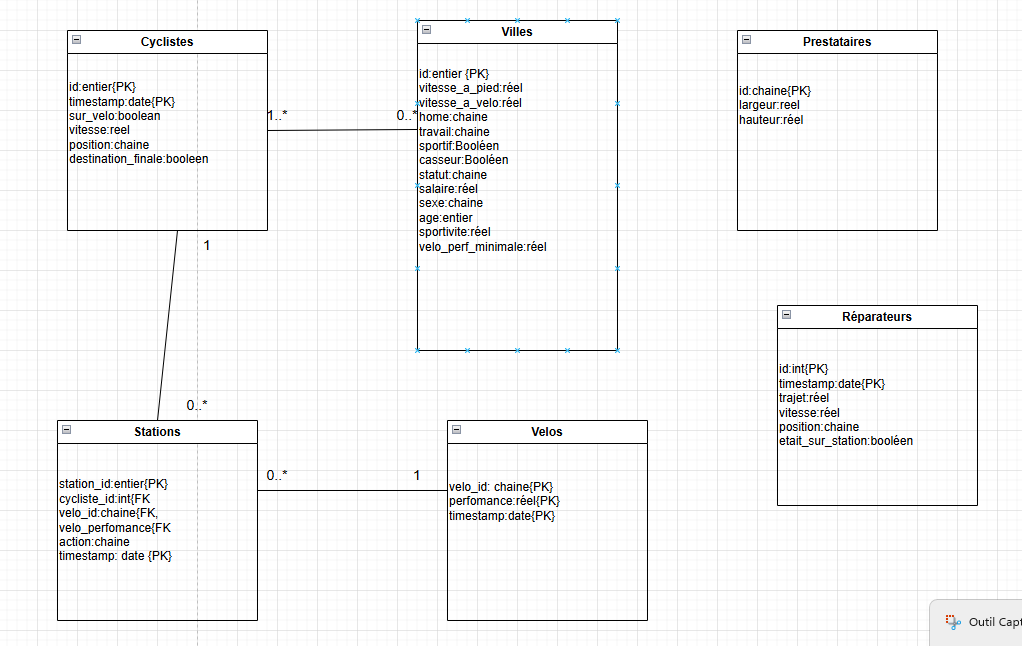

In [37]:

from pyspark.sql.functions import col
jointure = cycliste.join(villes, on="id", how="left_outer")
jointure.filter(col("id")==2).show()
jointure.count()

+---+-------------------+--------+-----+-------+--------------------+------------------+--------------+--------------+----+-------+-------+-------+------+-------+----+----+----------+------------------+
| id|          timestamp|sur_velo| velo|vitesse|            position|destination_finale|vitesse_a_pied|vitesse_a_velo|home|travail|sportif|casseur|statut|salaire|sexe| age|sportivite|velo_perf_minimale|
+---+-------------------+--------+-----+-------+--------------------+------------------+--------------+--------------+----+-------+-------+-------+------+-------+----+----+----------+------------------+
|  2|2018-01-01 00:01:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|          NULL|          NULL|NULL|   NULL|   NULL|   NULL|  NULL|   NULL|NULL|NULL|      NULL|              NULL|
|  2|2018-01-01 00:02:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|          NULL|          NULL|NULL|   NULL|   NULL|   NULL|  NULL|   NULL|NULL|NULL|      NULL|     

4868396

In [43]:
from pyspark.sql.functions import col
villes.filter(col("sportif")==True).count()


16

-Predire si un cycliste est un sportif ou pas,
-Prédire si on peut avoir des sportifs de plus de 400,
-Prédire la durée moyenne d'un trajet
-Prédire si un prestataire est majoritaire

Predire si c'est un sportif ou pas : random forest,modele logit, KNN, lstm

In [49]:
#modele pour predire le sexe
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


